In [1]:
# Step 1: Setup and Configuration
import numpy as np
import matplotlib.pyplot as plt
import os

# Import the classes from your script
# Make sure 'scint_toolkit_v5.py' is in the same directory
from scint_toolkit import DSA110Config, ScintillationPipeline

# --- User-defined parameters ---
# Replace with the actual path to your DSA-110 .npy file
NPY_PATH = "/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts/chromatica_dsa_I_272_368_2500b_cntr_bpc.npy"
EVENT_NAME = "chromatica"
OUTPUT_DIR = "./debug_output"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- Initialize the configuration and pipeline ---
print("Initializing configuration and pipeline...")
cfg = DSA110Config()
pipe = ScintillationPipeline(cfg, plot=True, )

print("\n--- Configuration Details ---")
print(f"Telescope Config: {type(cfg).__name__}")
print(f"Data is pre-channelised: {cfg.pre_channelised}")
print(f"ACF Method: {pipe.acf.__class__.__name__}")
print(f"Number of Lorentzian components to fit: {pipe.n_components}")

Initializing configuration and pipeline...

--- Configuration Details ---
Telescope Config: DSA110Config
Data is pre-channelised: True
ACF Method: PairCountACF
Number of Lorentzian components to fit: 2



Loading dynamic spectrum from: /arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts/chromatica_dsa_I_272_368_2500b_cntr_bpc.npy
Reading dynamic spectrum from .npy file: /arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts/chromatica_dsa_I_272_368_2500b_cntr_bpc.npy...
Input shape (6144, 2500) appears to be (freq, time). Transposing to (time, freq)...
New shape: (2500, 6144)
Successfully loaded data. Shape: (2500, 6144)
Data type: float32

This might indicate the data axes are swapped. The pipeline expects (time, frequency).
Transposed data to new shape: (2500, 6144)


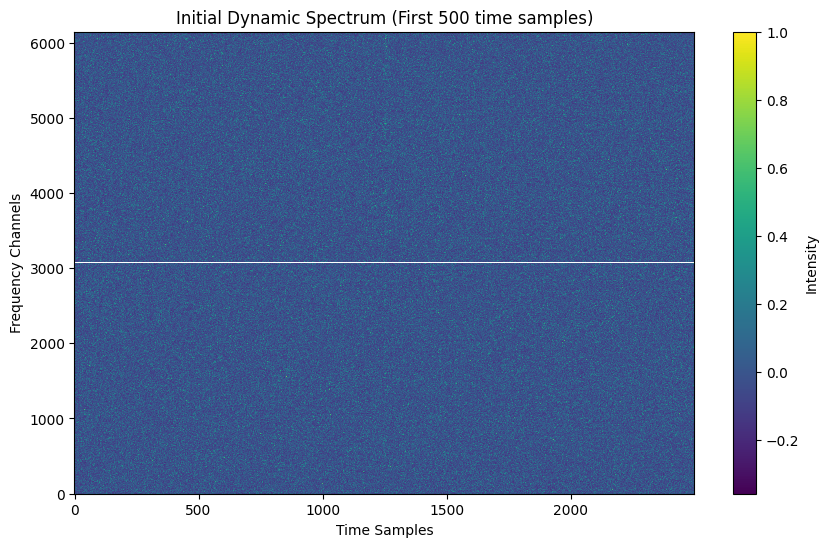

In [2]:
# Step 2: Data Loading and Initial Inspection

print(f"\nLoading dynamic spectrum from: {NPY_PATH}")
# The pipe._load() method calls the read_data method from your config
dyn = pipe._load(NPY_PATH)

# --- Debugging Checks ---
print(f"Successfully loaded data. Shape: {dyn.shape}")
print(f"Data type: {dyn.dtype}")

# This check is crucial. For dynamic spectra, we expect (time, frequency).
# Time is almost always the longer axis.
if dyn.shape[0] < dyn.shape[1]:
    print("\nWARNING: The number of time samples is less than the number of frequency channels.")
    print("This might indicate the data axes are swapped. The pipeline expects (time, frequency).")
    # If you know the axes are swapped, you can fix it here:
    # dyn = dyn.T
    print(f"Transposed data to new shape: {dyn.shape}")

# Plot a small portion of the dynamic spectrum to see if it looks reasonable
plt.figure(figsize=(10, 6))
plt.imshow(dyn[:, :].T, aspect='auto', origin='lower', interpolation='none')
plt.title(f"Initial Dynamic Spectrum (First 500 time samples)")
plt.xlabel("Time Samples")
plt.ylabel("Frequency Channels")
plt.colorbar(label="Intensity")
plt.show()


Detecting burst in the time series...
Burst detected in time slice: bins 1250 to 1263


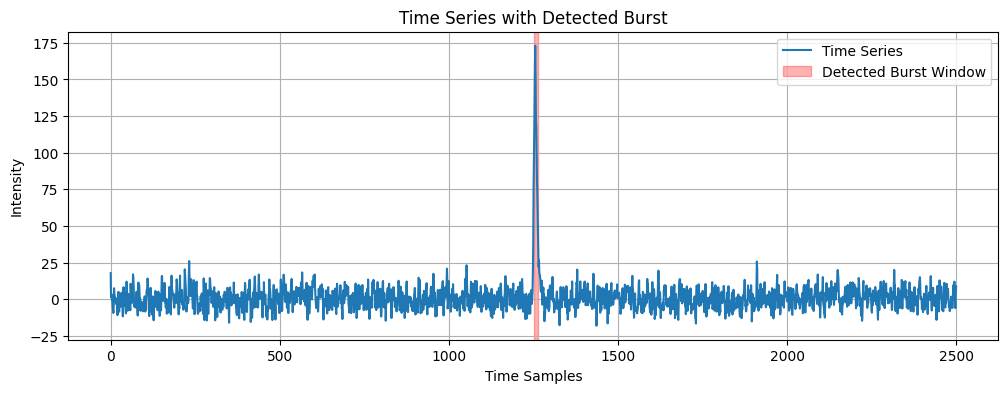

In [3]:
# Step 3: Automatic Burst Detection

print("\nDetecting burst in the time series...")
# Create the time series by summing along the frequency axis
time_series = np.nansum(dyn, axis=1)

try:
    # This calls the static method from the pipeline
    burst_slice_tuple = ScintillationPipeline.detect_burst(time_series, snr_thresh=7.0)
    t0, t1 = burst_slice_tuple
    print(f"Burst detected in time slice: bins {t0} to {t1}")

    # --- Debugging Plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(time_series, label="Time Series")
    plt.axvspan(t0, t1, color='red', alpha=0.3, label=f'Detected Burst Window')
    plt.title("Time Series with Detected Burst")
    plt.xlabel("Time Samples")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid(True)
    plt.show()

except RuntimeError as e:
    print(f"\nERROR in burst detection: {e}")
    print("The S/N threshold may be too high, or the burst is too faint.")
    # You can manually define the slice here to proceed with debugging:
    # t0, t1 = 1000, 1200 # Example manual slice
    # print(f"Using manual burst slice: bins {t0} to {t1}")


Applying bandpass correction using off-burst data...
Shape of off-burst dynamic spectrum used for template: (2487, 6144)
Bandpass correction applied.


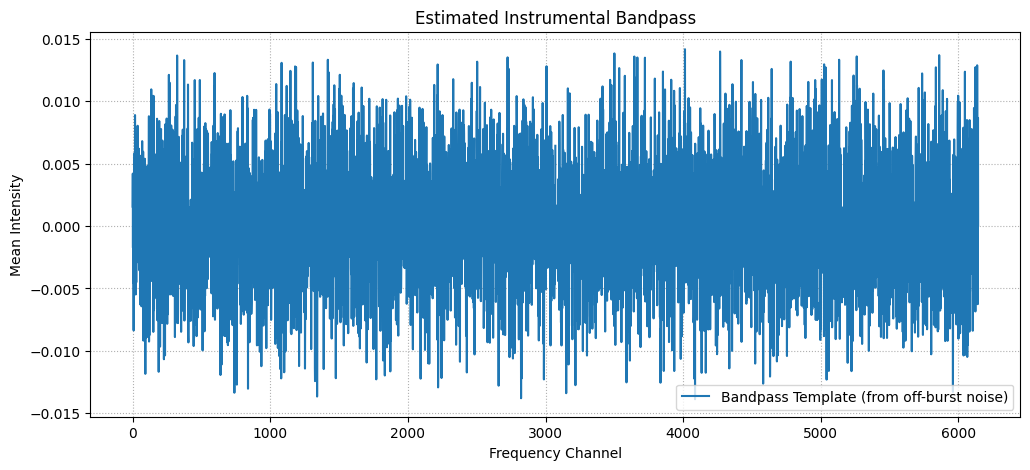

In [7]:
# Step 4: Bandpass Correction

print(f"\nApplying bandpass correction using off-burst data...")

# Define and check the off-burst region
off_dyn_parts = []
if t0 > 5: off_dyn_parts.append(dyn[:t0])
if t1 < len(dyn) - 5: off_dyn_parts.append(dyn[t1:])

if not off_dyn_parts:
    raise ValueError("No off-burst data available for bandpass correction!")

off_dyn = np.concatenate(off_dyn_parts, axis=0)
print(f"Shape of off-burst dynamic spectrum used for template: {off_dyn.shape}")

# Estimate and apply the bandpass template
template = pipe.ripple.estimate(off_dyn)
fdyn = pipe.ripple.apply(dyn, template)

print("Bandpass correction applied.")

# --- Debugging Plot ---
plt.figure(figsize=(12, 5))
plt.plot(template, label='Bandpass Template (from off-burst noise)')
plt.title("Estimated Instrumental Bandpass")
plt.xlabel("Frequency Channel")
plt.ylabel("Mean Intensity")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()


Extracting 1D spectra and calculating the ACF...
ACF calculation complete.


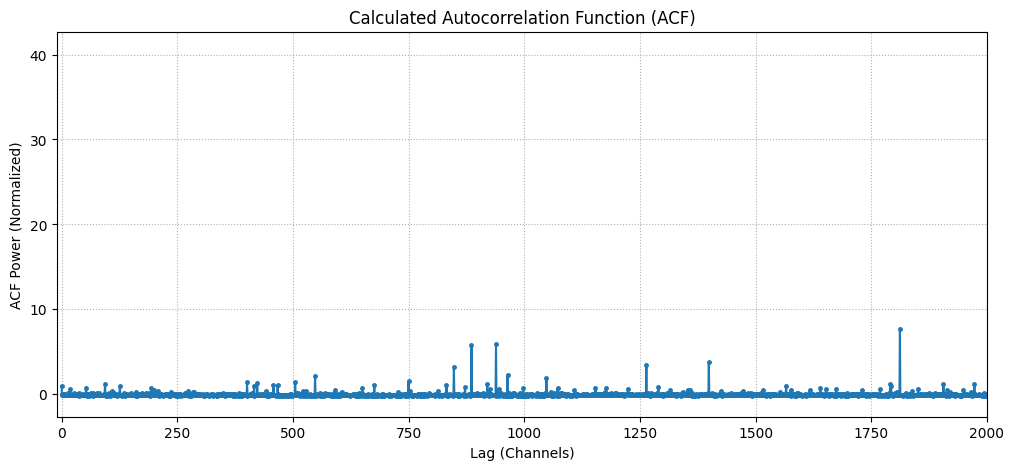

In [8]:
# Step 5: Spectrum Extraction and ACF Calculation

print("\nExtracting 1D spectra and calculating the ACF...")

# Extract the on-burst spectrum from the *corrected* dynamic spectrum
on_spectrum = np.nansum(fdyn[t0:t1], axis=0)

# Create the off-burst spectrum needed for proper normalization
off_spectrum = np.nansum(pipe.ripple.apply(off_dyn, template), axis=0)

# Create a valid channel mask
mask = np.isfinite(on_spectrum) & (on_spectrum > 0)

# Calculate the ACF
lag, acf = pipe.acf(on_spectrum, off_spectrum, mask=mask)

print("ACF calculation complete.")

# --- Debugging Plot ---
plt.figure(figsize=(12, 5))
plt.plot(lag, acf, '.-', markersize=5)
plt.title("Calculated Autocorrelation Function (ACF)")
plt.xlabel("Lag (Channels)")
plt.ylabel("ACF Power (Normalized)")
plt.xlim(-10, 2000) # Zoom in on interesting lags
plt.grid(True, linestyle=':')
plt.show()

In [15]:
# Step 6: Fitting the ACF

print("\nFitting the ACF with a multi-Lorentzian model...")

# Remove NaN values from ACF before fitting
valid_lags_mask = ~np.isnan(acf)
lag_fit, acf_fit = lags[valid_lags_mask], acf[valid_lags_mask]

# Data-driven initial guesses for the fitter
p0 = []
acf_peak = acf_fit[1] if pipe.acf.skip_zero and len(acf_fit) > 1 else acf_fit[0]
amps = np.geomspace(acf_peak, max(acf_peak / 10, 0.1), pipe.n_components)
widths = np.logspace(np.log10(2), np.log10(len(lag_fit) / 8), pipe.n_components)
params_0 = sorted(zip(amps, widths), key=lambda p: p[1])
p0 = [val for pair in params_0 for val in pair]

print(f"Using initial guess (p0) for fitter: {p0}")

try:
    fit_result = pipe.fitter(lag_fit, acf_fit, p0)
    popt = fit_result['params']

    print("\n--- Fit Results ---")
    for i in range(pipe.n_components):
        amp = popt[2*i]
        hwhm_chans = popt[2*i+1]
        hwhm_mhz = hwhm_chans * cfg.coarse_channel_hz / 1e6
        mod_ind = np.sqrt(amp)
        
        print(f"Component {i+1}:")
        print(f"  Modulation Index (sqrt(amp)): {mod_ind:.3f}")
        print(f"  Decorrelation Bandwidth (HWHM): {hwhm_chans:.2f} channels ({hwhm_mhz:.4f} MHz)")
    
    # --- Final Plot ---
    # Re-create fitter to plot components
    fitter = pipe.fitter
    model_curve = fitter.model(lag_fit, *popt)

    plt.figure(figsize=(10, 7))
    plt.plot(lag_fit, acf_fit, "k.", markersize=4, alpha=0.4, label="Data")
    plt.plot(lag_fit, model_curve, "r-", lw=2.5, label="Full Fit")
    
    # Plot individual components
    for i in range(pipe.n_components):
        comp_p = [0, 0] * pipe.n_components
        comp_p[2*i] = popt[2*i]
        comp_p[2*i+1] = popt[2*i+1]
        comp_curve = fitter.model(lag_fit, *comp_p)
        plt.plot(lag_fit, comp_curve, '--', lw=2, label=f'Component {i+1}')
    
    plt.title(f"Final ACF Fit for {EVENT_NAME}")
    plt.xlabel("Lag (Channels)")
    plt.ylabel("ACF Power")
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.xlim(0, 2000)
    plt.ylim(np.min(acf_fit)-0.1, np.max(acf_fit)*1.1)
    plt.show()

except RuntimeError as e:
    print(f"\nERROR during fitting: {e}")
    print("This may be caused by poor initial guesses or no clear feature to fit.")


Fitting the ACF with a multi-Lorentzian model...
Using initial guess (p0) for fitter: [-0.15521194688319914, 2.0, 0.1, 767.7500000000002]


/opt/pysetup/.venv/lib/python3.8/site-packages/numpy/core/function_base.py:431: RuntimeWarning: invalid value encountered in log10
  log_start = _nx.log10(start)


ValueError: `x0` is infeasible.

npy shape: (6144, 2500)


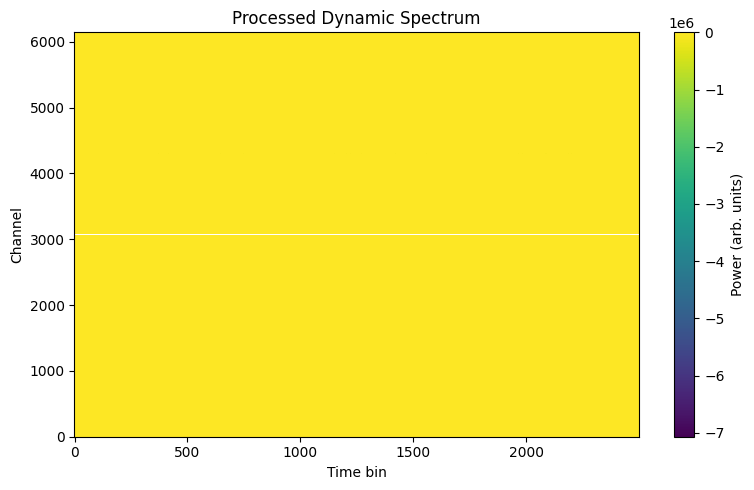

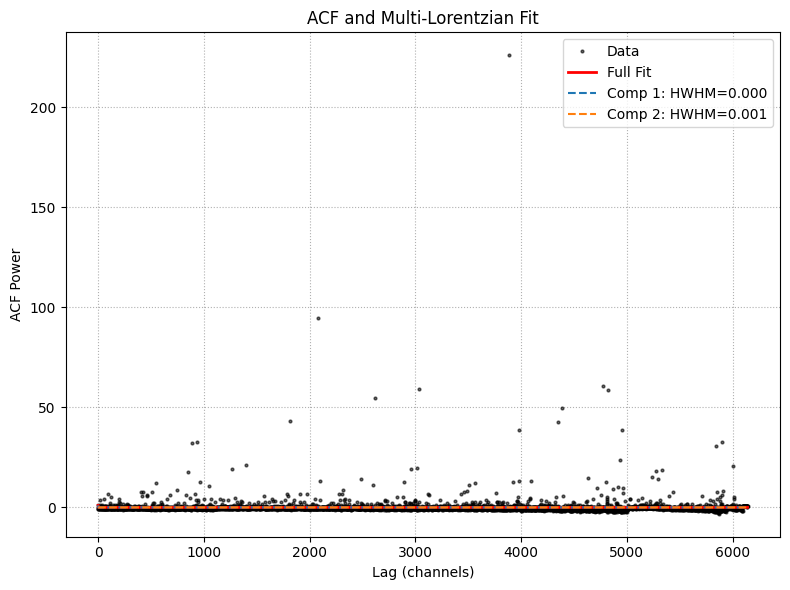

npy shape: (6144, 2500)


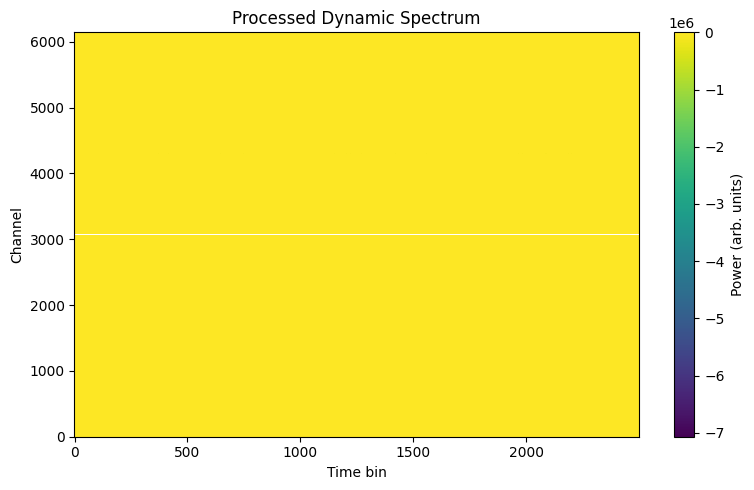

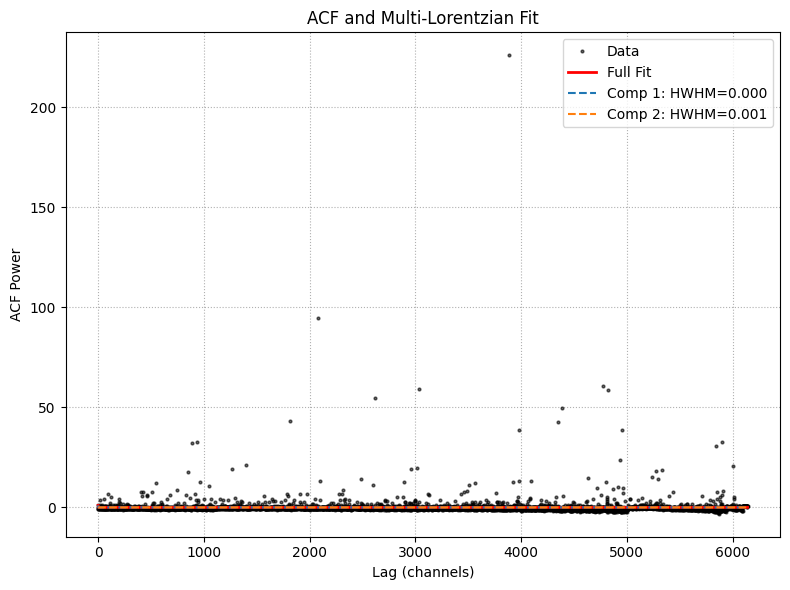

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import scint_toolkit
reload(scint_toolkit)
from scint_toolkit import DSA110Config, ScintillationPipeline, TelescopeConfig

npy_path = "/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts/chromatica_dsa_I_272_368_2500b_cntr_bpc.npy"

cfg   = scint_toolkit.DSA110Config()
pipe  = scint_toolkit.ScintillationPipeline(cfg, plot=True)
res   = pipe.run_full_analysis(npy_path)

cfg = DSA110Config()
cfg.pre_channelised = True        # force channelisation (rarely needed)
pipe = ScintillationPipeline(cfg, plot=True)
# .npy already holds (time, chan) power
result = pipe.run_full_analysis(npy_path)

In [ ]:


#pipe_chime = ScintillationPipeline(CHIMEConfig(), plot=True)
#result_chime = pipe_chime.run_full_analysis("chime_bbdata.raw")

In [ ]:
#burst_name = 'chromatica_dsa_I_272_368_2500b_cntr_bpc'
#basedir = '/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts'
#npy_path = os.path.join(basedir, f'{burst_name}.npy')
#print(f'Burst filepath: {npy_path}')
#
#burst = np.load(npy_path)
#plt.plot(np.nansum(burst, axis=0))

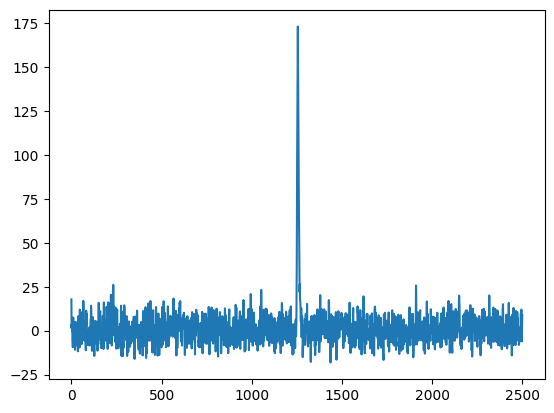

In [3]:
from typing import Tuple

ts = np.nansum(burst,axis=0)

def detect_burst(ts: np.ndarray, *, snr_thresh: float = 7.0) -> Tuple[int, int]:
        med = np.median(ts)
        mad = np.median(np.abs(ts - med))
        sigma = 1.4826 * mad
        mask = ts > med + snr_thresh * sigma
        if not mask.any():
            raise RuntimeError("No burst detected above threshold")
        starts = np.where(np.diff(np.concatenate(([0], mask, [0]))) == 1)[0]
        stops = np.where(np.diff(np.concatenate(([0], mask, [0]))) == -1)[0]
        seg = np.argmax(stops - starts)
        return int(starts[seg]), int(stops[seg])
    
bounds = detect_burst(ts, snr_thresh=7.0)

plt.plot(ts)
plt.axvline(bounds[0])
plt.axvline(bounds[1])

RuntimeError: No burst detected above threshold

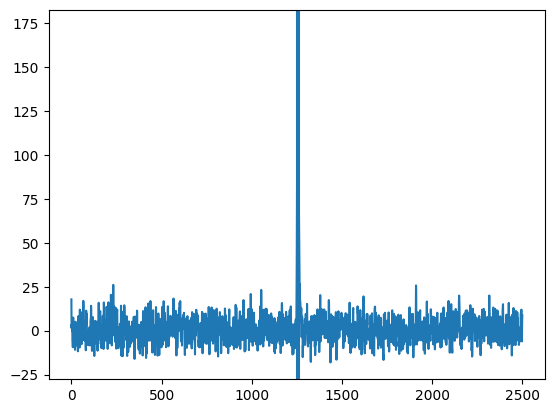

In [11]:
from typing import Tuple

ts = np.nansum(burst,axis=0)

def detect_burst(ts: np.ndarray, *, snr_thresh: float = 7.0) -> Tuple[int, int]:
        med = np.median(ts)
        mad = np.median(np.abs(ts - med))
        sigma = 1.4826 * mad
        mask = ts > med + snr_thresh * sigma
        if not mask.any():
            raise RuntimeError("No burst detected above threshold")
        starts = np.where(np.diff(np.concatenate(([0], mask, [0]))) == 1)[0]
        stops = np.where(np.diff(np.concatenate(([0], mask, [0]))) == -1)[0]
        seg = np.argmax(stops - starts)
        return int(starts[seg]), int(stops[seg])
    
bounds = detect_burst(ts, snr_thresh=7.0)

plt.plot(ts)
plt.axvline(bounds[0])
plt.axvline(bounds[1])

In [3]:
# ──────────────────────────────────────────────────────────────────────
# user‐defined parameters
file     = npy_path
peak     = None        # or None if unknown
cfg      = "dsa110"     # "chime" or "dsa110"
acf      = "pair"       # "pair" or "fft"
plot     = True         # or False
# ──────────────────────────────────────────────────────────────────────

from scint_toolkit import CHIMEConfig, DSA110Config, ScintillationPipeline
import numpy as np, json

cfg_map = {
    "chime": CHIMEConfig(),
    "dsa110": DSA110Config()
}
pipe = ScintillationPipeline(cfg_map[cfg], acf_method=acf, plot=plot)

burst_slice = (peak - 200, peak + 200) if peak is not None else None
res = pipe.run_full_analysis(file, burst_slice=burst_slice)

# format for JSON
res.pop("config", None)
j = {
    k: (v.tolist() if isinstance(v, np.ndarray) else v)
    for k, v in res.items()
}
print(json.dumps(j, indent=2))


TypeError: DSA-110 input file /arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts/chromatica_dsa_I_272_368_2500b_cntr_bpc.npy is not complex-valued.

In [7]:
#if __name__ == "__main__":  
#    import argparse
#    import json
#
#    p = argparse.ArgumentParser(description="Generalized Nimmo-style scintillation pipeline")
#    p.add_argument("file", help="Baseband complex voltage .npy file")
#    p.add_argument("--peak", type=int, help="Optional known burst peak index")
#    p.add_argument("--cfg", choices=["chime", "dsa110"], default="dsa110", help="Telescope configuration to use")
#    p.add_argument("--acf", choices=["pair", "fft"], default="pair", help="ACF calculation method")
#    p.add_argument("--plot", action="store_true", help="Show diagnostic plots")
#    args = p.parse_args()
#
#    cfg_map = {"chime": CHIMEConfig(), "dsa110": DSA110Config()}
#    pipe = ScintillationPipeline(cfg_map[args.cfg], acf_method=args.acf, plot=args.plot)
#
#    burst_slice = (args.peak - 200, args.peak + 200) if args.peak else None
#
#    res = pipe.run_full_analysis(args.file, burst_slice=burst_slice)
#
#    res.pop('config')
#    j = {k: v if isinstance(v, list) else v.tolist() if isinstance(v, np.ndarray) else v for k, v in res.items()}
#    print(json.dumps(j, indent=2))
#    return
#    

In [8]:
if __name__ == "__main__":  
    main()


usage: ipykernel_launcher.py [-h] [--peak PEAK] [--cfg {chime,dsa110}]
                             [--acf {pair,fft}] [--plot]
                             file
ipykernel_launcher.py: error: unrecognized arguments: -f


SystemExit: 2

In [ ]:
result = pipe.run_full_analysis(npy_path)   # auto-detects on-burst window